In [1]:
from graphviz import Digraph
from IPython.display import display
import pandas as pd

In [2]:
df_usecase_Q = pd.read_csv("./../data/mldl_usecase_questions.csv", encoding="utf-8-sig")
df_usecase_Q

,섹션ID,섹션,질문,질문 해설,대화자(우선순 정렬),답변,도메인_의존성,메모
0,1,비즈니스 문제 정의,비즈니스 목표를 SMART 방식으로 정의했는가?,"SMART = Specific(구체적), Measurable(측정가능), Achie...",PO/비즈니스 오너 ; PM/프로젝트 매니저 ; DS/데이터 사이언티스트 ; SME...,6개월 내 응급실 뇌졸중 환자의 치료 지연(door-to-needle) 60분 초과...,도메인-독립,NaN
1,1,비즈니스 문제 정의,"북극성 지표(NSM)는 무엇이며, 왜 그 지표인가?",NSM은 장기 가치와 직결되는 단 하나의 핵심 지표입니다. 선택 이유·계산식을 함께...,PO/비즈니스 오너 ; DS/데이터 사이언티스트 ; PM/프로젝트 매니저 ; SME...,"NSM=‘치료 지연 60분 초과 비율’. 임상 안전성과 환자 결과에 직접 연결되고,...",도메인-독립,NaN
2,1,비즈니스 문제 정의,현재 베이스라인(성과/비용/시간)은?,현재 상태를 수치로 고정해 이후 개선효과 비교 기준을 만듭니다(기간/표본/출처 포함).,DS/데이터 사이언티스트 ; DE/데이터 엔지니어 ; PM/프로젝트 매니저,"최근 3개월 평균 치료 지연 60분 초과 34%, CT 판독 대기 38분, 재검률 ...",도메인-독립,NaN
3,1,비즈니스 문제 정의,주 사용자/페르소나와 기대치는?,주 사용자(역할·목표·고통점)와 핵심 시나리오를 정의합니다.,UX/제품 ; PO/비즈니스 오너 ; PM/프로젝트 매니저,"응급의: triage 경보 정확/빠름, 방사선과: 오탐 최소·설명 제공, 코디네이터...",도메인-독립,NaN
4,1,비즈니스 문제 정의,업무 흐름 어디에 개입하는가?,모델이 어느 단계에서 어떤 입력/출력으로 의사결정에 기여하는지 명확히 합니다.,SME/도메인 전문가 ; UX/제품 ; MLE/ML 엔지니어 ; PM/프로젝트 매니저,CT 업로드 직후 전처리→의심소견 스코어링→우선 판독 큐 재정렬→의사 화면에 하이라...,도메인-독립,NaN
...,...,...,...,...,...,...,...,...
73,8,실행 및 배포 로드맵,모니터링(성능/드리프트/공정성/SLA)은?,운영 성능·드리프트·공정성·SLA 알림/대시보드를 설계합니다.,MLE/ML 엔지니어 ; SRE/플랫폼/DevOps ; DS/데이터 사이언티스트,Evidently 리포트·Prometheus 메트릭·Grafana 대시보드·알림 설정.,도메인-독립,NaN
74,8,실행 및 배포 로드맵,Incident 대응(온콜/포스트모템)은?,장애 등급·온콜·사후 분석 프로세스를 명시합니다.,SRE/플랫폼/DevOps ; PM/프로젝트 매니저 ; MLE/ML 엔지니어,"온콜 로테이션, Sev 등급 기준 대응, 72시간 내 포스트모템.",도메인-독립,NaN
75,8,실행 및 배포 로드맵,재학습 트리거/주기/승인 흐름은?,단계별 목표·승인 게이트·책임자를 명확히 합니다.,PM/프로젝트 매니저 ; PO/비즈니스 오너,"월간 재학습 기본, 드리프트 임계 초과 시 즉시 재학습, CAB 승인 필요.",도메인-독립,NaN
76,8,실행 및 배포 로드맵,문서화/교육/가이드는?,모델/데이터/시스템 카드와 사용자 교육 계획을 포함합니다.,PM/프로젝트 매니저 ; DS/데이터 사이언티스트 ; 데이터 거버넌스,"모델카드/데이터카드/시스템카드, 사용자 교육 세션 월 1회.",도메인-독립,NaN


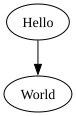

In [3]:
dot = Digraph(comment="뇌졸중 ", format="png")
dot.node("A","Hello")
dot.node("B","World")
dot.edge("A","B")
display(dot)          # 노트북에 바로 렌더


In [5]:
df = df_usecase_Q.copy()
if not isinstance(df, pd.DataFrame):
    raise TypeError(f"df is {type(df)}; DataFrame이 아닙니다.")

required = {"섹션ID","섹션","질문"}
missing = required - set(df.columns)
if missing:
    raise KeyError(f"누락 컬럼: {missing}")